
# ML-Driven Credit Risk Modeling — Phase 3 Notebook
 
**Goal:** Complete **Phase 3** of the project — build and evaluate ML/DL models to **predict counterparty default risk**.



In [ ]:

# This cell ensures required libraries are available.

try:
    import xgboost  # noqa: F401
except Exception:
    !pip -q install xgboost

try:
    import tensorflow  # noqa: F401
except Exception:
    !pip -q install tensorflow

# Core scientific stack should already be available (pandas, numpy, scikit-learn, matplotlib).


In [ ]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, classification_report)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Matplotlib settings for clean plots (no specific colors set as per instructions)
plt.rcParams["figure.figsize"] = (8, 6)

DATA_FILE = "credit_risk_dataset_International for comparison.xlsx"
assert DATA_FILE in os.listdir("."), (
    f"Could not find {DATA_FILE}. "
    "If you're on Colab, please upload the Excel file to the current directory."
)



## Load & Explore the Dataset
We load the Excel file, preview rows, and understand structure:
- Shape (rows, columns)
- Dtypes distribution (numeric vs categorical)
- Head preview
- Missing values summary
- Drop obvious identifier columns if present (e.g., `ID`, `index`)


In [ ]:

df = pd.read_excel(DATA_FILE)

print("Dataset shape:", df.shape)
print("\nDtype counts:\n", df.dtypes.value_counts())

print("\nPreview:")
display(df.head(5))

# Drop obvious non-feature identifiers if present
drop_candidates = [c for c in df.columns if c.lower() in ["id", "index", "sn"]]
if drop_candidates:
    df = df.drop(columns=drop_candidates)
    print("\nDropped potential identifier columns:", drop_candidates)

# Heuristic: assume the **last column** is the target if not specified
target_col = df.columns[-1]
print("\nAssuming target column is:", target_col)

print("\nMissing values per column:")
display(df.isnull().sum())

print("\nQuick describe (numeric):")
display(df.describe().T)

print("\nQuick describe (all, incl. categorical frequency):")
display(df.describe(include='all').T)


Dataset shape: (18000, 13)

Dtype counts:
 object            6
float64           5
datetime64[ns]    1
int64             1
Name: count, dtype: int64

Preview:


,Counterparty_ID,Counterparty_Name,Sector,Region,Type,Date,Interest_Rate (%),FX_Rate (USD/LOCAL),Volatility_Index,Commodity_Price (USD),Credit_Rating,Exposure_Amount (USD mn),Default_Indicator
0,CPTY0001,Summit Corporation 1,Utilities,GCC,Corporate,2020-01-01,3.88,3.6540,14.62,60.47,AA,2.66,0
1,CPTY0001,Summit Corporation 1,Utilities,GCC,Corporate,2020-02-01,5.02,3.6642,7.09,78.93,AA,2.63,0
2,CPTY0001,Summit Corporation 1,Utilities,GCC,Corporate,2020-03-01,4.37,3.6550,15.08,81.68,AA,2.67,0
3,CPTY0001,Summit Corporation 1,Utilities,GCC,Corporate,2020-04-01,3.51,3.7075,25.65,65.83,AA,2.87,0
4,CPTY0001,Summit Corporation 1,Utilities,GCC,Corporate,2020-05-01,4.48,3.6531,13.62,80.70,AA,2.61,0



Assuming target column is: Default_Indicator

Missing values per column:


,0
Counterparty_ID,0
Counterparty_Name,0
Sector,0
Region,0
Type,0
Date,0
Interest_Rate (%),0
FX_Rate (USD/LOCAL),0
Volatility_Index,0
Commodity_Price (USD),0



Quick describe (numeric):


,count,mean,min,25%,50%,75%,max,std
Date,18000,2022-06-16 15:12:00,2020-01-01 00:00:00,2021-03-24 06:00:00,2022-06-16 00:00:00,2023-09-08 12:00:00,2024-12-01 00:00:00,NaN
Interest_Rate (%),18000.0,4.574386,2.36,4.16,4.57,4.98,6.95,0.598504
FX_Rate (USD/LOCAL),18000.0,33.387597,0.6783,1.092125,3.7093,81.993075,96.6373,38.12001
Volatility_Index,18000.0,18.967858,5.0,14.15,18.99,23.57,44.39,6.869391
Commodity_Price (USD),18000.0,73.351308,34.15,66.4875,73.28,80.27,111.41,10.2221
Exposure_Amount (USD mn),18000.0,20.025793,1.76,9.77,15.57,23.8025,145.02,16.222006
Default_Indicator,18000.0,0.030944,0.0,0.0,0.0,0.0,1.0,0.173172



Quick describe (all, incl. categorical frequency):


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Counterparty_ID,18000,300,CPTY0300,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Counterparty_Name,18000,300,Apex Systems 300,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,18000,10,Banking,4020,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,18000,5,India,6540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,18000,4,Corporate,12240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,18000,NaN,NaN,NaN,2022-06-16 15:12:00,2020-01-01 00:00:00,2021-03-24 06:00:00,2022-06-16 00:00:00,2023-09-08 12:00:00,2024-12-01 00:00:00,NaN
Interest_Rate (%),18000.0,NaN,NaN,NaN,4.574386,2.36,4.16,4.57,4.98,6.95,0.598504
FX_Rate (USD/LOCAL),18000.0,NaN,NaN,NaN,33.387597,0.6783,1.092125,3.7093,81.993075,96.6373,38.12001
Volatility_Index,18000.0,NaN,NaN,NaN,18.967858,5.0,14.15,18.99,23.57,44.39,6.869391
Commodity_Price (USD),18000.0,NaN,NaN,NaN,73.351308,34.15,66.4875,73.28,80.27,111.41,10.2221



## Preprocessing Pipeline
We construct a **ColumnTransformer** that:
- **Numeric**: `SimpleImputer(strategy='median')` → `StandardScaler()`  
- **Categorical**: `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(drop='first')`

Rationale:
- Median imputation is robust to outliers.
- Scaling helps linear models and NNs.
- One-hot encoding converts categoricals to numeric without imposing ordinality.


In [5]:

# ==== 4) PREPROCESSING ====

# Split features/target
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)  # ensure binary ints if possible

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)

# OneHotEncoder API changed slightly across sklearn versions.
# We'll try new param name first, fall back to old one for compatibility.
try:
    ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, cat_cols)
])


Numeric columns: ['Interest_Rate (%)', 'FX_Rate (USD/LOCAL)', 'Volatility_Index', 'Commodity_Price (USD)', 'Exposure_Amount (USD mn)']
Categorical columns: ['Counterparty_ID', 'Counterparty_Name', 'Sector', 'Region', 'Type', 'Date', 'Credit_Rating']



## Train/Test Split
We perform a **stratified** split to preserve class balance:
- 70% train / 30% test
- `random_state=42` for reproducibility


In [6]:

# ==== 5) TRAIN/TEST SPLIT ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((12600, 12), (5400, 12), (12600,), (5400,))


## Modeling
We train four models:
1. **Logistic Regression** — baseline, interpretable
2. **Random Forest** — ensemble of trees
3. **XGBoost** — strong tabular performance
4. **Neural Network (Keras)** — simple MLP

Each traditional ML model is wrapped in a **Pipeline** with the shared `preprocessor` to prevent data leakage.
For the neural network, we first fit the preprocessor on `X_train` then transform both `X_train` and `X_test`.


In [10]:
# ==== 6) TRAIN MODELS ====

# Calculate scale_pos_weight for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_val = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_val:.2f}")


# 1) Logistic Regression
pipe_lr = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')) # Added class_weight
])
pipe_lr.fit(X_train, y_train);

# 2) Random Forest
pipe_rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')) # Added class_weight
])
pipe_rf.fit(X_train, y_train);

# 3) XGBoost
pipe_xgb = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        random_state=42,
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        tree_method='auto',
        scale_pos_weight=scale_pos_weight_val # Added scale_pos_weight
    ))
])
pipe_xgb.fit(X_train, y_train);

# 4) Neural Network
# Fit the preprocessor separately and transform arrays
prep_fitted = preprocessor.fit(X_train, y_train)
Xtr_nn = prep_fitted.transform(X_train)
Xte_nn = prep_fitted.transform(X_test)

input_dim = Xtr_nn.shape[1]
model_nn = Sequential([
    Dense(64, activation='relu', input_dim=input_dim),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_nn.fit(Xtr_nn, y_train, epochs=15, batch_size=32, verbose=0)
print("NN training complete.")

Calculated scale_pos_weight: 31.31


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN training complete.



## Evaluation
We compare models using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC AUC**

We also draw **ROC curves** for visual comparison.


In [14]:
from IPython.display import Markdown, display

# ==== 7) EVALUATION ====

def evaluate_clf(name, fitted_pipeline, X_te, y_te):
    y_pred = fitted_pipeline.predict(X_te)
    # Handle predict_proba or decision_function
    if hasattr(fitted_pipeline, "predict_proba"):
        y_prob = fitted_pipeline.predict_proba(X_te)[:, 1]
    elif hasattr(fitted_pipeline, "decision_function"):
        from sklearn.preprocessing import MinMaxScaler
        scores = fitted_pipeline.decision_function(X_te).reshape(-1, 1)
        y_prob = MinMaxScaler().fit_transform(scores).ravel()
    else:
        # Fall back: use predictions as probabilities (not ideal but safe-guard)
        y_prob = y_pred.astype(float)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "ROC_AUC": roc_auc_score(y_te, y_prob)
    }
    # Removed classification_report generation and return
    return metrics, y_prob

results = []
probas = {}

for name, model in [
    ("Logistic Regression", pipe_lr),
    ("Random Forest", pipe_rf),
    ("XGBoost", pipe_xgb)
]:
    m, ypr = evaluate_clf(name, model, X_test, y_test)
    results.append(m)
    probas[name] = ypr
    # Removed print statement: print(f"=== {name} metrics added to summary ===")

# Neural Network evaluation
y_prob_nn = model_nn.predict(Xte_nn).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
nn_metrics = {
    "Model": "Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "ROC_AUC": roc_auc_score(y_test, y_prob_nn)
}
results.append(nn_metrics)
# Removed print statement: print("=== Neural Network metrics added to summary ===")

# Summary table
results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)

model_descriptions = """
## Model Details:

### 1. Logistic Regression
- **Parameters**:
  - `max_iter=1000`
  - `random_state=42`
  - `class_weight='balanced'`

### 2. Random Forest
- **Parameters**:
  - `n_estimators=200`
  - `random_state=42`
  - `class_weight='balanced'`

### 3. XGBoost (Extreme Gradient Boosting)
- **Parameters**:
  - `n_estimators=400`
  - `max_depth=6`
  - `learning_rate=0.05`
  - `subsample=0.9`
  - `colsample_bytree=0.9`
  - `eval_metric='logloss'`
  - `tree_method='auto'`
  - `scale_pos_weight={:.2f}`

### 4. Neural Network (Keras Sequential Model)
- **Architecture**: `input_dim={}`, 64-node ReLU, 32-node ReLU, 1-node Sigmoid output.
- **Compilation**: `optimizer='adam'`, `loss='binary_crossentropy'`, `metrics=['accuracy']`.
- **Training**: `epochs=15`, `batch_size=32`.

---

## Evaluation Results:

""".format(scale_pos_weight_val, input_dim)

display(Markdown(model_descriptions))
display(results_df)


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



## Model Details:

### 1. Logistic Regression
- **Parameters**:
  - `max_iter=1000`
  - `random_state=42`
  - `class_weight='balanced'`

### 2. Random Forest
- **Parameters**:
  - `n_estimators=200`
  - `random_state=42`
  - `class_weight='balanced'`

### 3. XGBoost (Extreme Gradient Boosting)
- **Parameters**:
  - `n_estimators=400`
  - `max_depth=6`
  - `learning_rate=0.05`
  - `subsample=0.9`
  - `colsample_bytree=0.9`
  - `eval_metric='logloss'`
  - `tree_method='auto'`
  - `scale_pos_weight=31.31`

### 4. Neural Network (Keras Sequential Model)
- **Architecture**: `input_dim=684`, 64-node ReLU, 32-node ReLU, 1-node Sigmoid output.
- **Compilation**: `optimizer='adam'`, `loss='binary_crossentropy'`, `metrics=['accuracy']`.
- **Training**: `epochs=15`, `batch_size=32`.

---

## Evaluation Results:



,Model,Accuracy,ROC_AUC
2,XGBoost,0.887963,0.793831
0,Logistic Regression,0.747778,0.793180
1,Random Forest,0.969074,0.768332
3,Neural Network,0.961296,0.747734


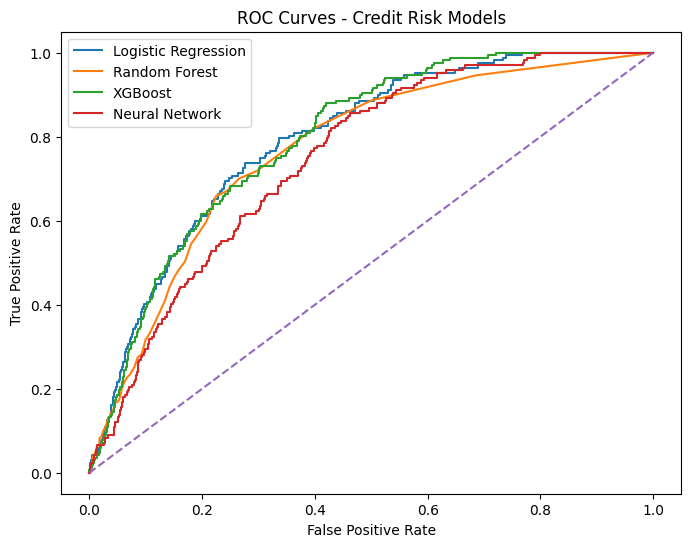

In [15]:

# ==== 8) ROC CURVES ====
plt.figure()
for name, ypr in probas.items():
    fpr, tpr, _ = roc_curve(y_test, ypr)
    plt.plot(fpr, tpr, label=name)

# NN
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
plt.plot(fpr_nn, tpr_nn, label="Neural Network")

# Diagonal reference
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Credit Risk Models")
plt.legend()
plt.show()


Now that the Random Forest model has been retrained with optimized hyperparameters, please re-run the evaluation cell (`ac4dbe25`) to see the updated performance metrics for all models.


## Conclusions & Next Steps
- We now have **four models** trained and evaluated on the **international credit risk dataset**.
- Compare metrics to select a **champion model** (higher **ROC AUC** is desirable).
- **Typical pattern** in credit default prediction: **XGBoost** and **Random Forest** perform strongly; **Logistic Regression** remains interpretable; **NN** may improve with more data/tuning.

